In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import os
%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
# from matplotlib.ticker import FormatStrFormatter



## Get split half reliability from TIMIT data

In [2]:
df_paths = list(Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/').glob('*dataset*.pdpkl'))
# df_path = df_paths[:] # want sets 1 & 2 for now

In [3]:
# stim meta df
meta_df = []
for path in df_paths:
    df = pd.read_pickle(path)
    df['stim_subset'] = int(re.search('dataset_(-?\d+)', path.stem).group(0).split('_')[-1])
    meta_df.append(df)
meta_df = pd.concat(meta_df, axis=0)


# human results df  
results_path = Path('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/')
# results_df = pd.read_csv(results_path / 'Batch_367265_batch_results.csv')

# results_files = [file for file in results_path.glob("*.csv") if file.stem != "Batch_367574_batch_results" ]

results_files = list(results_path.glob("*.csv"))


## Get condition map to translate stimuli file names to relevant condition variables
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']

# file_name = truth['stim_file_name'][100]

def file_name_to_labels(file_name):
    file = Path(file_name)
    word = re.search('word_(-?\d+)', file.stem).group(0).split('_')[-1]
    word = class_map[int(word)]
    orig_df_ix = re.search('stim_(-?\d+)', file.stem).group(0).split('_')[-1]
    orig_dataset_ix = re.search('set_(-?\d+)', file.stem).group(0).split('_')[-1]
    if 'ssn' in file.stem:
        cond = 'ssn'
        speaker_sex = 'ssn'
    elif "catch_trial" not in file.as_posix():
        cond = re.search('cond_(-?\d+)', file.stem).group(0).split('_')[-1]
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    if "catch_trial" in file.as_posix():
        snr = 'clean'
        cond = 'catch_trial'
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    else:
        snr = re.search('snr_(-?\d+)', file.stem).group(0).split('_')[-1]
    return int(orig_dataset_ix), word, snr, cond, speaker_sex, int(orig_df_ix)



# human results df

# Get data from each batch file 
dfs = []
for ix, file in enumerate(results_files):
    df = pd.read_csv(file)
    df = df.rename(index={ix:f'p{ix}' for ix in range(len(df))})

    truth = df[[col for col in list(df) if 'Audio_Exp' in col]]
    truth = truth.T
    truth = truth.rename(index={ix:f"trial {ix.split('_')[-1]}" for ix in truth.index})
    truth = truth.dropna(axis='columns')
    truth = pd.melt(truth.reset_index(), 
                    id_vars=['index'], 
                    var_name = 'participant',
                    value_name = 'stim_path',
                    ignore_index=False)

    responses = df[[col for col in list(df) if 'Resp_Exp' in col]]
    responses = responses.T
    responses = responses.rename(columns={0:"guessed_word"}, index={ix:f"trial {ix.split('_')[-1]}" for ix in responses.index})
    responses = responses.dropna(axis='columns')

    responses = pd.melt(responses.reset_index(), 
                    id_vars=['index'], 
                    var_name = 'participant',
                    value_name = 'guessed_word',
                    ignore_index=False)

    results = responses.merge(truth, on=['index', 'participant'])
    results['participant'] = results['participant'] + f'_{ix}' 

    results['stim_subset'], results['true_word'], results['snr'], results['distractor_condition'], results['target_sex'], results['orig_df_ix'] = zip(*results['stim_path'].map(file_name_to_labels))

    ## Get distractor information from dfs 
    for stim_subset in results.stim_subset.unique():
        # get ixs for samples with this dataset
        result_ixs = np.where(results.stim_subset == stim_subset)[0]
        # get matching metadata
        meta_subset = meta_df[meta_df.stim_subset == stim_subset]
        results.loc[result_ixs, 'distractor_words'] = meta_subset.loc[results.loc[result_ixs, 'orig_df_ix'], ['distractor_words']].values
        results.loc[result_ixs, 'distractor_sex'] = meta_subset.loc[results.loc[result_ixs, 'orig_df_ix'], ['distractor_sex']].values
    dfs.append(results)
results = pd.concat(dfs)
print(results.shape)


# filter for participants that passed the catch trials

len(results.participant.unique())
results['accuracy'] = (results['guessed_word'] == results['true_word']).astype('int')
get_confusion = lambda row: int(row.guessed_word in row.distractor_words)

results['confusions'] = results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)
catch_trial_particiapnt_performance = results[results.distractor_condition == 'catch_trial'].groupby('participant').accuracy.mean()
# filter out bad performers on catch trials  
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance > 9/12].index
good_results = results[results.participant.isin(good_participants)]


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from r

(9100, 12)


In [12]:
# flatten columns
flat_participant_results = (good_results.groupby(['participant', 'snr','distractor_condition']).accuracy.mean().reset_index())

In [81]:
stats.pearsonr(group_1, group_2).statistic

1.0

In [139]:
from tqdm.auto import tqdm
import scipy.stats as stats

np.random.seed(0)
n_parts = flat_participant_results.participant.nunique()
max_split_size = n_parts // 2
# run power analysis computing split half reliability for each split size

conds = flat_participant_results['cond_str'].unique()
unique_participants = flat_participant_results.participant.unique()

split_half_reliabilities = []
n_boots = 1000
for k in tqdm(range(6, max_split_size+1)):
    for cond in tqdm(conds, leave=False):
        split_corrs = np.zeros(n_boots)
        cond_results = flat_participant_results[flat_participant_results.cond_str == cond]
        for i in range(n_boots):
            # get group 1
            group_1_names = np.random.choice(unique_participants, k, replace=False)
            group_1 = cond_results[cond_results.participant.isin(group_1_names)].accuracy.values
            # get group 2
            group_2_names = np.random.choice(unique_participants[~np.isin(unique_participants, group_1_names)], k, replace=False)
            group_2 = cond_results[cond_results.participant.isin(group_2_names)].accuracy.values
            # get r
            p = stats.pearsonr(group_1, group_2).statistic 
            split_corrs[i] = (2 * p) / (1 + p) # split half reliability w correction  
        # get condition mean and std
        split_half_reliabilities.append({"k":k, "cond":cond, "mean_cor":np.nanmean(split_corrs), "std": np.nanstd(split_corrs)})

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

/tmp/ipykernel_20922/1814163429.py:27: RuntimeWarning: divide by zero encountered in double_scalars
  split_corrs[i] = (2 * p) / (1 + p) # split half reliability w correction


  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

In [140]:
power_analysis_df = pd.DataFrame(split_half_reliabilities) 

# get snr and cond as separate columns
power_analysis_df['snr'] = power_analysis_df.cond.apply(lambda x: x.split('dB')[0].split('_')[-1])
power_analysis_df['dist'] = power_analysis_df.cond.apply(lambda x: x.split('_')[0])

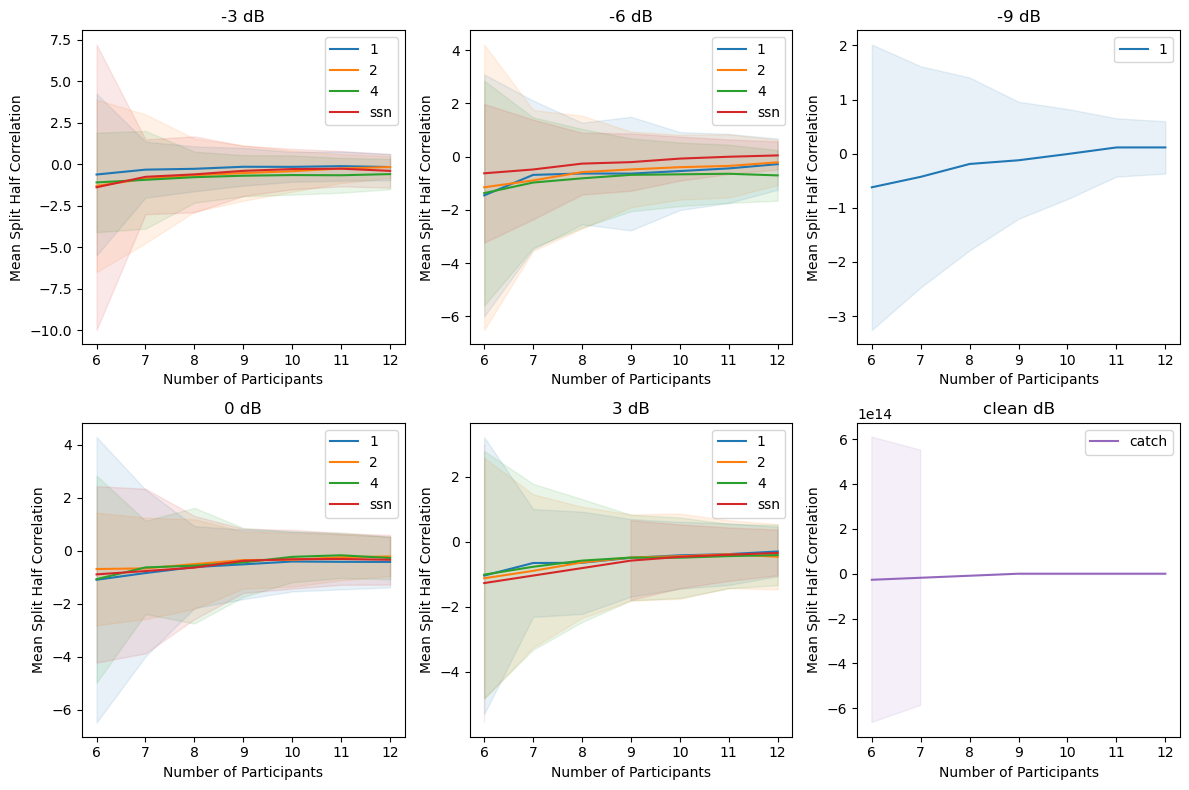

In [150]:
# plot 
fig, ax = plt.subplots(2, 3, figsize=(12,8))
axs = ax.flatten()
# make palette for snr
palette = sns.color_palette("tab10", len(power_analysis_df.dist.unique()))

for s_ix, snr in enumerate(power_analysis_df.snr.unique()):
    for p_ix, dist in enumerate(power_analysis_df.dist.unique()):

        cond_df = power_analysis_df[(power_analysis_df.snr == snr) & (power_analysis_df.dist == dist)]
        sns.lineplot(data=cond_df,
                      x='k', y='mean_cor',
                      color=palette[p_ix],
                      ax=axs[s_ix], label=f'{dist}')
        # add error bars 
        y = cond_df.mean_cor.values
        yerr = cond_df['std'].values
        x = cond_df.k.values
        axs[s_ix].fill_between(x, y-yerr, y+yerr, alpha=0.1, color=palette[p_ix])
    axs[s_ix].set_xlabel('Number of Participants')
    axs[s_ix].set_ylabel('Mean Split Half Correlation')
    axs[s_ix].set_title(f'{snr} dB')
    # axs[p_ix].set_ylim(-3,3)

    # ax.legend()

plt.tight_layout()

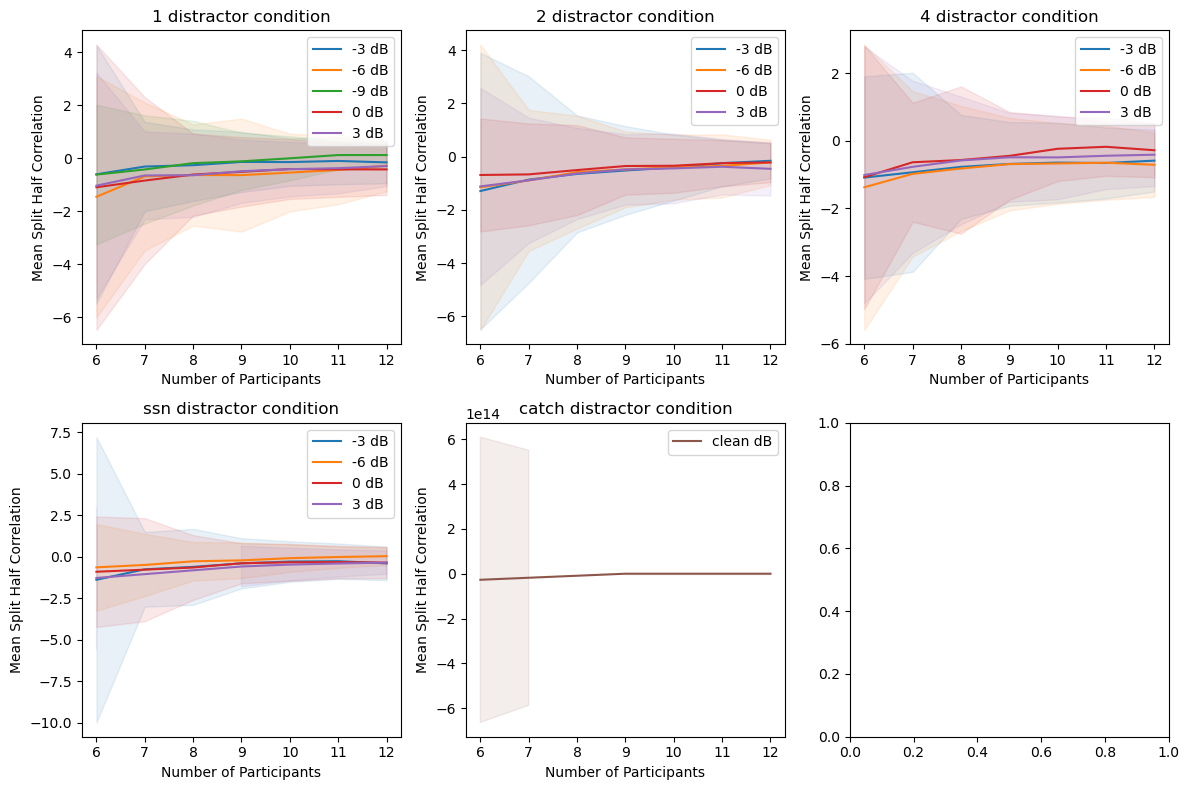

In [148]:
# plot 
fig, ax = plt.subplots(2, 3, figsize=(12,8))
axs = ax.flatten()
# make palette for snr
palette = sns.color_palette("tab10", len(power_analysis_df.snr.unique()))

for p_ix, dist in enumerate(power_analysis_df.dist.unique()):
    for s_ix, snr in enumerate(power_analysis_df.snr.unique()):
        cond_df = power_analysis_df[(power_analysis_df.snr == snr) & (power_analysis_df.dist == dist)]
        sns.lineplot(data=cond_df,
                      x='k', y='mean_cor',
                      color=palette[s_ix],
                      ax=axs[p_ix], label=f'{snr} dB')
        # add error bars 
        y = cond_df.mean_cor.values
        yerr = cond_df['std'].values
        x = cond_df.k.values
        axs[p_ix].fill_between(x, y-yerr, y+yerr, alpha=0.1, color=palette[s_ix])
    axs[p_ix].set_xlabel('Number of Participants')
    axs[p_ix].set_ylabel('Mean Split Half Correlation')
    axs[p_ix].set_title(f'{dist} distractor condition')
    # axs[p_ix].set_ylim(-3,3)

    # ax.legend()

plt.tight_layout()